# Stan Conjugate 1D Gaussian Demo

This notebook runs CmdStanPy's mean-field ADVI for the conjugate 1D Gaussian model in `1dgaussian.stan`, comparing Stan's default variational settings with an increased-`grad_samples` run and `pathfinder`. The plotting follows the `simpleVI/single_MC/1dgaussian_knownvar` convention: posterior standard deviation on top, posterior mean below, with the exact conjugate posterior in red.


In [1]:
from pathlib import Path
import re
import subprocess
# import warnings
# import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cmdstanpy import CmdStanModel, write_stan_json

plt.rcParams.update({'font.size': 20})
# warnings.filterwarnings("ignore", message="The default behavior of CmdStanVB.stan_variable")


/Users/madelynandersen/miniconda3/envs/stan3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
candidate_dirs = [
    Path.cwd(),
    Path.cwd() / "paper_vignettes" / "stan_conj1dgaussian_demo",
]

for candidate_dir in candidate_dirs:
    if (candidate_dir / "1dgaussian.stan").exists():
        NOTEBOOK_DIR = candidate_dir.resolve()
        break
else:
    raise FileNotFoundError("Could not find 1dgaussian.stan from the current notebook working directory.")

STAN_FILE = NOTEBOOK_DIR / "1dgaussian.stan"
OUTPUT_DIR = NOTEBOOK_DIR / "cmdstan_output"
OUTPUT_DIR.mkdir(exist_ok=True)

model = CmdStanModel(stan_file=str(STAN_FILE))


## Data and Exact Posterior

The data generation mirrors the random-restart 1D Gaussian notebooks: 100 observations from a normal likelihood centered at 3, likelihood standard deviation 1, and prior `mu ~ Normal(0, 10)`. The model is conjugate, so the exact posterior mean and standard deviation are available analytically.


In [3]:
mu_prior, sigma_prior = 0.0, 10.0
sigma_like = 1.0
n_obs = 100
mu_like = 3.0
DATA_SEED = 0


def gaussian_1d(n_samples=100, mu_like=5.0, sigma_like=1.0, seed=20):
    np.random.seed(seed)
    return np.random.normal(mu_like, sigma_like, n_samples)


def gaussian_1d_posterior(data, mu_prior=0.0, sigma_prior=1.0, sigma_like=10.0):
    data = np.asarray(data, dtype=float)
    n = data.size
    posterior_precision = 1 / sigma_prior**2 + n / sigma_like**2
    posterior_variance = 1 / posterior_precision
    posterior_mean = posterior_variance * (mu_prior / sigma_prior**2 + data.sum() / sigma_like**2)
    return posterior_mean, np.sqrt(posterior_variance)


y_data = gaussian_1d(n_obs, mu_like=mu_like, sigma_like=sigma_like, seed=DATA_SEED)
true_mu_post, true_sigma_post = gaussian_1d_posterior(
    y_data,
    mu_prior=mu_prior,
    sigma_prior=sigma_prior,
    sigma_like=sigma_like,
)

stan_data = {
    "N": int(y_data.size),
    "y": y_data,
    "sigma": float(sigma_like),
    "mu_prior": float(mu_prior),
    "sigma_prior": float(sigma_prior),
}

pd.DataFrame(
    {
        "quantity": ["N", "sample mean", "exact posterior mean", "exact posterior std"],
        "value": [len(y_data), y_data.mean(), true_mu_post, true_sigma_post],
    }
)


,quantity,value
0,N,100.000000
1,sample mean,3.059808
2,exact posterior mean,3.059502
3,exact posterior std,0.099995


## Stan Fits

`save_latent_dynamics=True` writes the ADVI ELBO history to CmdStan's diagnostic CSV. CmdStan does not save per-iteration variational means and standard deviations, so posterior mean/std comparisons below use the final variational samples.

For this diagnostic run, ADVI is configured with `iter=300_000` and a tiny relative-objective tolerance so the comparison is not dominated by Stan stopping after only a few ELBO checks.

In [4]:
SEED = 12
inc_grad_samples = 100
ADVI_ITERS = 300_000
ADVI_EVAL_ELBO = 10_000
ADVI_TOL_REL_OBJ = 1e-16

DEFAULT_LABEL = "Stan ADVI default"
GRAD_LABEL = f"Stan ADVI grad_samples={inc_grad_samples}"
PATHFINDER_LABEL = "Stan Pathfinder"

RUN_OUTPUT_DIR = OUTPUT_DIR / f"seed{SEED}_grad{inc_grad_samples}_iter{ADVI_ITERS}"
RUN_OUTPUT_DIR.mkdir(exist_ok=True)


def method_output_dir(name):
    path = RUN_OUTPUT_DIR / name
    path.mkdir(exist_ok=True)
    return path


advi_default = model.variational(
    data=stan_data,
    seed=SEED,
    iter=ADVI_ITERS,
    eval_elbo=ADVI_EVAL_ELBO,
    tol_rel_obj=ADVI_TOL_REL_OBJ,
    require_converged=False,
    save_latent_dynamics=True,
    output_dir=method_output_dir("advi_default"),
    time_fmt="%Y%m%d%H%M%S%f",
)

advi_grad_inc = model.variational(
    data=stan_data,
    seed=SEED,
    grad_samples=inc_grad_samples,
    iter=ADVI_ITERS,
    eval_elbo=ADVI_EVAL_ELBO,
    tol_rel_obj=ADVI_TOL_REL_OBJ,
    require_converged=False,
    save_latent_dynamics=True,
    output_dir=method_output_dir(f"advi_grad_samples_{inc_grad_samples}"),
    time_fmt="%Y%m%d%H%M%S%f",
)

pathfinder_fit = model.pathfinder(
    data=stan_data,
    seed=SEED,
    output_dir=method_output_dir("pathfinder"),
    time_fmt="%Y%m%d%H%M%S%f",
)


21:19:14 - cmdstanpy - INFO - Chain [1] start processing


21:19:15 - cmdstanpy - INFO - Chain [1] done processing


21:19:15 - cmdstanpy - WARNING - The algorithm may not have converged.
Proceeding because require_converged is set to False


21:19:15 - cmdstanpy - INFO - Chain [1] start processing


21:19:21 - cmdstanpy - INFO - Chain [1] done processing


21:19:21 - cmdstanpy - WARNING - The algorithm may not have converged.
Proceeding because require_converged is set to False


21:19:21 - cmdstanpy - INFO - Chain [1] start processing


21:19:21 - cmdstanpy - INFO - Chain [1] done processing


In [5]:
def _scalar(x):
    return float(np.asarray(x).squeeze())


def summarize_vb_fit(label, fit):
    samples = np.asarray(fit.stan_variable("mu", mean=False), dtype=float).reshape(-1)
    mean = _scalar(fit.stan_variable("mu", mean=True))
    return {
        "method": label,
        "mu_mean": mean,
        "mu_std": float(samples.std(ddof=1)),
        "n_draws": int(samples.size),
        "csv_file": fit.runset.csv_files[0],
        "diagnostic_file": fit.runset.diagnostic_files[0],
    }


def _first_csv_file(fit):
    runset = getattr(fit, "_runset", None)
    if runset is None:
        return None
    return runset.csv_files[0]


def summarize_pathfinder_fit(label, fit):
    samples = np.asarray(fit.stan_variable("mu"), dtype=float).reshape(-1)
    return {
        "method": label,
        "mu_mean": float(samples.mean()),
        "mu_std": float(samples.std(ddof=1)),
        "n_draws": int(samples.size),
        "csv_file": _first_csv_file(fit),
        "diagnostic_file": None,
    }


summary = pd.DataFrame(
    [
        summarize_vb_fit(DEFAULT_LABEL, advi_default),
        summarize_vb_fit(GRAD_LABEL, advi_grad_inc),
        summarize_pathfinder_fit(PATHFINDER_LABEL, pathfinder_fit),
    ]
)
summary["mu_mean_error"] = summary["mu_mean"] - true_mu_post
summary["mu_mean_abs_error_true_sds"] = summary["mu_mean_error"].abs() / true_sigma_post
summary["mu_std_error"] = summary["mu_std"] - true_sigma_post
summary["mu_std_relative_error"] = summary["mu_std_error"] / true_sigma_post


def _stdout_text(fit):
    stdout_files = getattr(fit.runset, "stdout_files", [])
    if not stdout_files:
        return ""
    return Path(stdout_files[0]).read_text(errors="ignore")


def summarize_advi_stdout(label, fit):
    text = _stdout_text(fit)
    eta_match = re.search(r"Found best value \[eta = ([^\]]+)\]", text)
    notes = []
    for phrase in [
        "MAY BE DIVERGING",
        "MEDIAN ELBO CONVERGED",
        "The ELBO at a previous iteration is larger than the ELBO upon convergence",
        "The maximum number of iterations is reached",
    ]:
        if phrase in text:
            notes.append(phrase)
    return {
        "method": label,
        "adapted_eta": eta_match.group(1) if eta_match else None,
        "stan_notes": "; ".join(notes),
    }


advi_run_notes = pd.DataFrame(
    [
        summarize_advi_stdout(DEFAULT_LABEL, advi_default),
        summarize_advi_stdout(GRAD_LABEL, advi_grad_inc),
    ]
)

summary_cols = [
    "method", "mu_mean", "mu_std",
    "mu_mean_error", "mu_mean_abs_error_true_sds",
    "mu_std_error", "mu_std_relative_error",
    "n_draws", "csv_file", "diagnostic_file",
]

display(summary[summary_cols])
advi_run_notes


21:19:21 - cmdstanpy - WARNING - The default behavior of CmdStanVB.stan_variable(mean=True) will change in a future release to always return a numpy.ndarray, even for scalar variables.


21:19:21 - cmdstanpy - WARNING - The default behavior of CmdStanVB.stan_variable(mean=True) will change in a future release to always return a numpy.ndarray, even for scalar variables.


,method,mu_mean,mu_std,mu_mean_error,mu_mean_abs_error_true_sds,mu_std_error,mu_std_relative_error,n_draws,csv_file,diagnostic_file
0,Stan ADVI default,3.060571,0.101589,0.001069,0.010690,0.001594,0.015939,1000,/Users/madelynandersen/Documents/VB Bakeoff/si...,/Users/madelynandersen/Documents/VB Bakeoff/si...
1,Stan ADVI grad_samples=100,2.989736,0.104818,-0.069766,0.697693,0.004823,0.048229,1000,/Users/madelynandersen/Documents/VB Bakeoff/si...,/Users/madelynandersen/Documents/VB Bakeoff/si...
2,Stan Pathfinder,3.068487,0.101114,0.008985,0.089859,0.001119,0.011189,1000,/Users/madelynandersen/Documents/VB Bakeoff/si...,NaN


,method,adapted_eta,stan_notes
0,Stan ADVI default,1,The maximum number of iterations is reached
1,Stan ADVI grad_samples=100,100,The maximum number of iterations is reached


In [6]:
def read_advi_elbo_history(fit, label):
    diagnostic_path = Path(fit.runset.diagnostic_files[0])
    rows = []
    for line in diagnostic_path.read_text().splitlines():
        line = line.strip()
        if not line:
            continue
        if line.startswith("#"):
            line = line[1:].strip()
        parts = [part.strip() for part in line.split(",")]
        if len(parts) != 3 or parts[0] == "iter":
            continue
        try:
            rows.append((int(float(parts[0])), float(parts[1]), float(parts[2])))
        except ValueError:
            continue
    history = pd.DataFrame(rows, columns=["iter", "time_in_seconds", "ELBO"])
    history["method"] = label
    return history


elbo_history = pd.concat(
    [
        read_advi_elbo_history(advi_default, DEFAULT_LABEL),
        read_advi_elbo_history(advi_grad_inc, GRAD_LABEL),
    ],
    ignore_index=True,
)
elbo_history.tail()


,iter,time_in_seconds,ELBO,method
55,260000,5.712,-147.75371,Stan ADVI grad_samples=100
56,270000,5.927,-147.61758,Stan ADVI grad_samples=100
57,280000,6.145,-147.83759,Stan ADVI grad_samples=100
58,290000,6.362,-147.41643,Stan ADVI grad_samples=100
59,300000,6.578,-147.46923,Stan ADVI grad_samples=100


## Fixed-Eta Diagnostic

Stan's ADVI default does not keep eta fixed when `grad_samples` changes. During adaptation Stan tries eta values in the order `100, 10, 1, 0.1, 0.01`, running only a short adaptation window for each candidate. This diagnostic disables eta adaptation and runs both `grad_samples=1` and `grad_samples=100` at each candidate eta for `300_000` iterations, so the two gradient-sample settings can be compared at the same optimizer scale.

,grad_samples,eta,mu_mean,mu_std,mu_mean_error,mu_mean_abs_error_true_sds,mu_std_error,mu_std_relative_error,final_elbo,best_elbo,n_elbo_evals,returncode
0,1,100.00,2.930827,0.069615,-0.128675,1.286811,-0.030380,-0.303818,-148.33341,-147.28855,30,0
5,100,100.00,3.138380,0.092405,0.078878,0.788816,-0.007590,-0.075902,-147.54858,-147.29089,30,0
1,1,10.00,3.051573,0.095579,-0.007929,0.079296,-0.004416,-0.044163,-147.33777,-147.16191,30,0
6,100,10.00,3.063061,0.096081,0.003559,0.035589,-0.003914,-0.039141,-147.24988,-147.17855,30,0
2,1,1.00,3.066988,0.102261,0.007486,0.074866,0.002266,0.022661,-147.32263,-147.16443,30,0
7,100,1.00,3.062662,0.097286,0.003160,0.031605,-0.002709,-0.027092,-147.24741,-147.18322,30,0
3,1,0.10,3.062376,0.103667,0.002874,0.028741,0.003672,0.036724,-147.32432,-147.16047,30,0
8,100,0.10,3.061327,0.097450,0.001825,0.018250,-0.002545,-0.025447,-147.24716,-147.17945,30,0
4,1,0.01,3.060038,0.104375,0.000536,0.005363,0.004380,0.043799,-147.32616,-147.15092,30,0
9,100,0.01,3.059983,0.097579,0.000481,0.004815,-0.002416,-0.024162,-147.24716,-147.17878,30,0


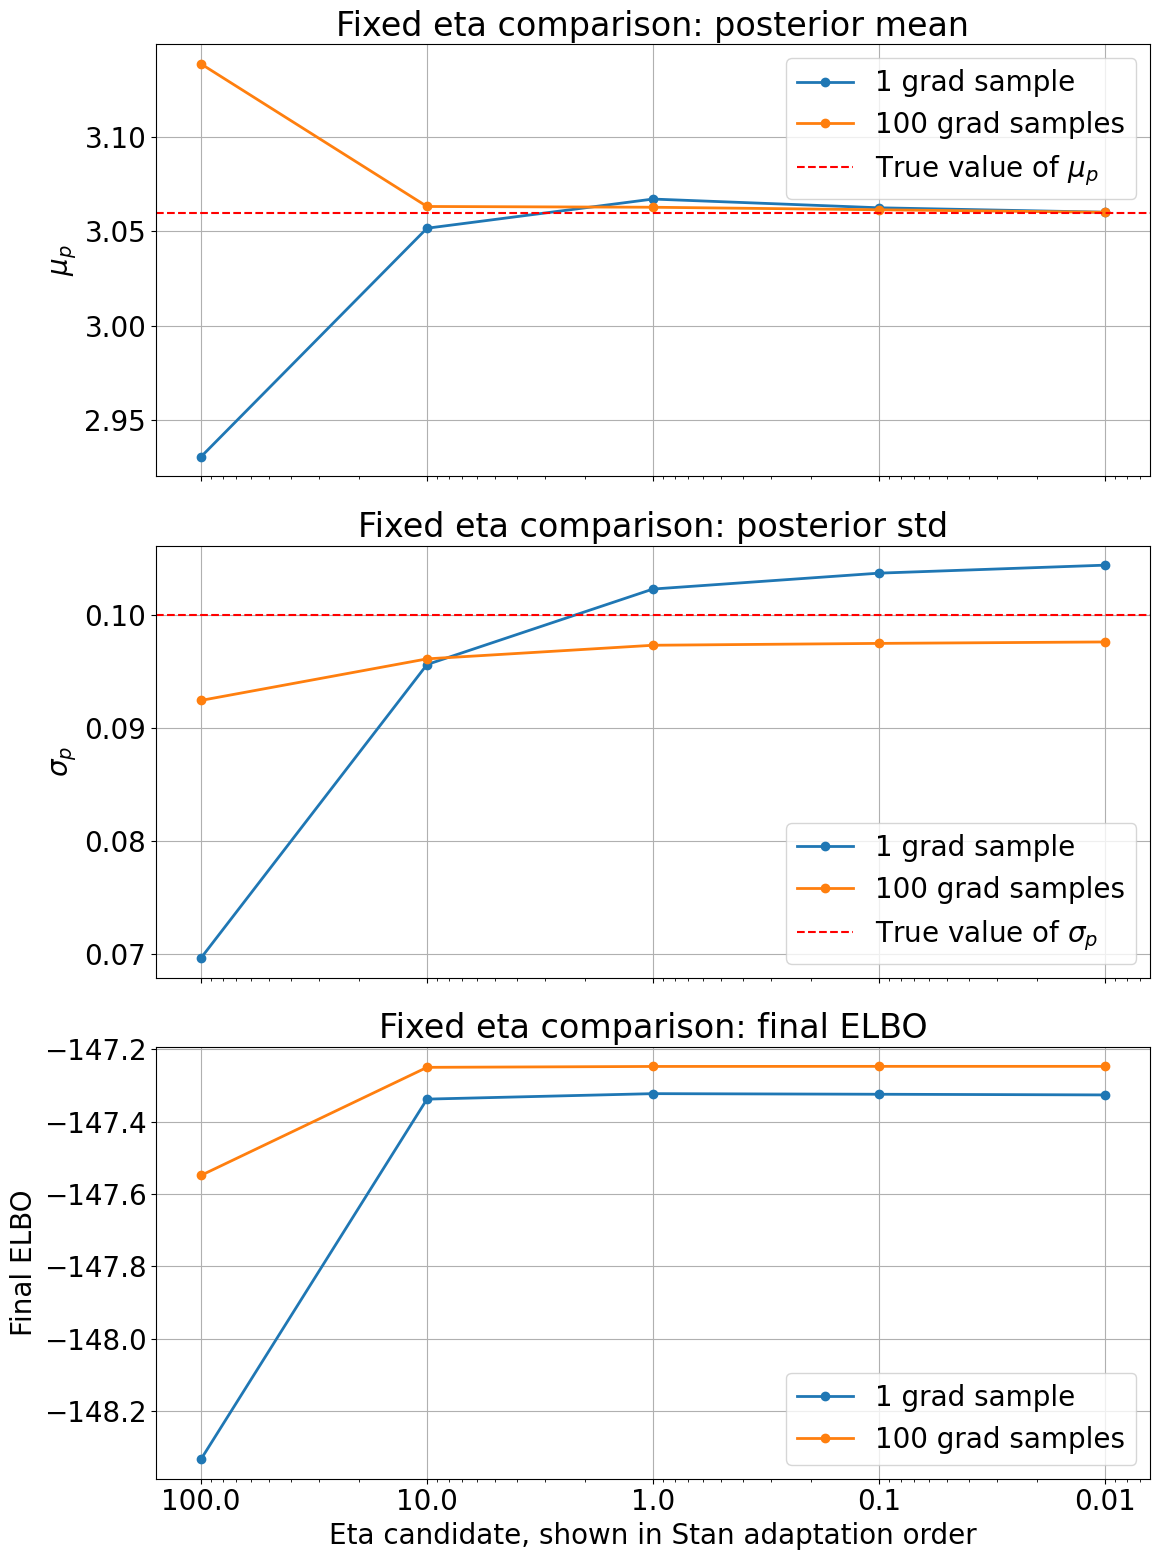

In [7]:
ETA_SEQUENCE = [100.0, 10.0, 1.0, 0.1, 0.01]
FIXED_ETA_DIR = RUN_OUTPUT_DIR / "fixed_eta_grid"
FIXED_ETA_DIR.mkdir(exist_ok=True)
DATA_JSON = RUN_OUTPUT_DIR / "stan_data.json"
write_stan_json(str(DATA_JSON), stan_data)


def _eta_label(eta):
    return str(eta).replace(".", "p")


def _read_variational_csv(csv_path):
    header = None
    rows = []
    for line in Path(csv_path).read_text(errors="ignore").splitlines():
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        if header is None:
            header = [part.strip() for part in line.split(",")]
        else:
            rows.append([float(part) for part in line.split(",")])
    if header is None or not rows:
        raise ValueError(f"No variational draws found in {csv_path}")
    mu_idx = header.index("mu")
    mean_row = rows[0][mu_idx]
    samples = np.asarray([row[mu_idx] for row in rows[1:]], dtype=float)
    return {
        "mu_mean": float(mean_row),
        "sample_mean": float(samples.mean()),
        "mu_std": float(samples.std(ddof=1)),
        "n_draws": int(samples.size),
    }


def _read_elbo_csv(diagnostic_path):
    rows = []
    for line in Path(diagnostic_path).read_text(errors="ignore").splitlines():
        line = line.strip()
        if not line:
            continue
        if line.startswith("#"):
            line = line[1:].strip()
        parts = [part.strip() for part in line.split(",")]
        if len(parts) != 3 or parts[0] == "iter":
            continue
        try:
            rows.append((int(float(parts[0])), float(parts[1]), float(parts[2])))
        except ValueError:
            continue
    history = pd.DataFrame(rows, columns=["iter", "time_in_seconds", "ELBO"])
    if history.empty:
        return {"final_elbo": np.nan, "best_elbo": np.nan, "n_elbo_evals": 0}
    return {
        "final_elbo": float(history["ELBO"].iloc[-1]),
        "best_elbo": float(history["ELBO"].max()),
        "n_elbo_evals": int(len(history)),
    }


def run_fixed_eta_advi(grad_samples, eta):
    run_dir = FIXED_ETA_DIR / f"grad_samples_{grad_samples}" / f"eta_{_eta_label(eta)}"
    run_dir.mkdir(parents=True, exist_ok=True)
    csv_path = run_dir / "output.csv"
    diagnostic_path = run_dir / "diagnostic.csv"
    stdout_path = run_dir / "stdout.txt"

    cmd = [
        str(model.exe_file),
        "random", f"seed={SEED}",
        "data", f"file={DATA_JSON}",
        "output", f"file={csv_path}", f"diagnostic_file={diagnostic_path}", "refresh=100",
        "method=variational", "algorithm=meanfield",
        f"iter={ADVI_ITERS}", f"eval_elbo={ADVI_EVAL_ELBO}", f"tol_rel_obj={ADVI_TOL_REL_OBJ}",
        f"grad_samples={grad_samples}", f"eta={eta}",
        "adapt", "engaged=0",
    ]
    completed = subprocess.run(cmd, capture_output=True, text=True)
    stdout_path.write_text(completed.stdout + completed.stderr)

    row = {
        "grad_samples": grad_samples,
        "eta": eta,
        "returncode": completed.returncode,
        "csv_file": str(csv_path),
        "diagnostic_file": str(diagnostic_path),
    }
    if completed.returncode == 0:
        row.update(_read_variational_csv(csv_path))
        row.update(_read_elbo_csv(diagnostic_path))
    else:
        row.update({
            "mu_mean": np.nan, "sample_mean": np.nan, "mu_std": np.nan,
            "n_draws": 0, "final_elbo": np.nan, "best_elbo": np.nan, "n_elbo_evals": 0,
        })
    row["mu_mean_error"] = row["mu_mean"] - true_mu_post
    row["mu_mean_abs_error_true_sds"] = abs(row["mu_mean_error"]) / true_sigma_post
    row["mu_std_error"] = row["mu_std"] - true_sigma_post
    row["mu_std_relative_error"] = row["mu_std_error"] / true_sigma_post
    return row


fixed_eta_summary = pd.DataFrame(
    [run_fixed_eta_advi(grad_samples, eta) for grad_samples in [1, inc_grad_samples] for eta in ETA_SEQUENCE]
)
fixed_eta_summary["abs_mu_mean_error"] = fixed_eta_summary["mu_mean_error"].abs()
fixed_eta_summary["abs_mu_std_error"] = fixed_eta_summary["mu_std_error"].abs()

cols = [
    "grad_samples", "eta", "mu_mean", "mu_std",
    "mu_mean_error", "mu_mean_abs_error_true_sds",
    "mu_std_error", "mu_std_relative_error",
    "final_elbo", "best_elbo", "n_elbo_evals", "returncode",
]
display(fixed_eta_summary[cols].sort_values(["eta", "grad_samples"], ascending=[False, True]))

fig, axs = plt.subplots(3, 1, figsize=(12, 16), sharex=True)
for grad_samples, group in fixed_eta_summary.groupby("grad_samples"):
    group = group.sort_values("eta", ascending=False)
    label = f"{grad_samples} grad sample" + ("s" if grad_samples != 1 else "")
    axs[0].plot(group["eta"], group["mu_mean"], marker="o", linewidth=2, label=label)
    axs[1].plot(group["eta"], group["mu_std"], marker="o", linewidth=2, label=label)
    axs[2].plot(group["eta"], group["final_elbo"], marker="o", linewidth=2, label=label)

axs[0].axhline(true_mu_post, color="red", linestyle="--", label=r"True value of $\mu_p$")
axs[0].set_ylabel(r"$\mu_p$")
axs[0].set_title("Fixed eta comparison: posterior mean")
axs[0].grid()
axs[0].legend()

axs[1].axhline(true_sigma_post, color="red", linestyle="--", label=r"True value of $\sigma_p$")
axs[1].set_ylabel(r"$\sigma_p$")
axs[1].set_title("Fixed eta comparison: posterior std")
axs[1].grid()
axs[1].legend()

axs[2].set_ylabel("Final ELBO")
axs[2].set_xlabel("Eta candidate, shown in Stan adaptation order")
axs[2].set_title("Fixed eta comparison: final ELBO")
axs[2].grid()
axs[2].legend()

for ax in axs:
    ax.set_xscale("log")
    ax.invert_xaxis()
    ax.set_xticks(ETA_SEQUENCE)
    ax.set_xticklabels([str(eta) for eta in ETA_SEQUENCE])

plt.tight_layout()
plt.show()


### Why the Adapted Eta Can Be Worse

The 300k fixed-eta grid shows that `grad_samples=100` is not intrinsically worse. Once the fixed-eta runs are allowed to continue long enough, the 100-gradient-sample runs are generally as good as or better than the 1-gradient-sample runs at the same eta value. Even eta `100`, which looked bad in the shorter run, is much less pathological after 300k iterations.

The main adapted `grad_samples=100` run can still be worse because Stan's eta adaptation chooses eta `100`, while the default 1-gradient-sample run chooses eta `1`. Eta `100` is still an aggressive optimizer scale: in the fixed-eta grid it remains worse than the better 100-gradient-sample choices (`1`, `0.1`, and `0.01`) by the true-posterior-SD-scaled mean error.

One subtlety: an adapted eta-`100` run is not identical to the fixed eta-`100` run with adaptation disabled. The adaptation phase consumes random numbers before the final stochastic-gradient phase, so even after the variational parameters are reset, the subsequent Monte Carlo gradient sequence is different. The fixed-eta grid is therefore best read as an optimizer-scale diagnostic, not as a byte-for-byte replay of Stan's adapted run.

The lesson is that changing `grad_samples` changes the stochastic path used by Stan's eta-selection heuristic. The higher-gradient-sample run can make eta `100` look acceptable during the short adaptation window, but a smaller eta gives better final posterior summaries.


## Fixed-Eta Gradient/ELBO MC Grid

This follow-up keeps eta fixed and crosses gradient Monte Carlo samples with ELBO Monte Carlo samples: `grad_samples in {1, 100}` and `elbo_samples in {1, 100}`. This separates the stochastic gradient estimate from the stochastic ELBO estimate used for monitoring/convergence.


,elbo_samples,grad_samples,eta,mu_mean,mu_std,mu_mean_abs_error_true_sds,mu_std_relative_error,final_elbo,best_elbo,n_elbo_evals,returncode
0,1,1,100.00,3.077210,0.127849,0.177087,0.278557,-146.59421,-146.53429,30,0
5,1,100,100.00,3.131090,0.098756,0.715917,-0.012391,-146.89037,-146.85293,30,0
1,1,1,10.00,3.024618,0.101146,0.348858,0.011513,-146.98792,-146.74342,30,0
6,1,100,10.00,3.082674,0.102017,0.231729,0.020222,-147.08312,-146.82197,30,0
2,1,1,1.00,3.047781,0.104260,0.117220,0.042654,-146.85363,-146.79689,30,0
7,1,100,1.00,3.063350,0.102281,0.038480,0.022856,-147.23571,-146.83138,30,0
3,1,1,0.10,3.058679,0.103877,0.008233,0.038821,-146.82486,-146.79412,30,0
8,1,100,0.10,3.060789,0.102290,0.012870,0.022955,-147.25884,-146.83544,30,0
4,1,1,0.01,3.058897,0.104034,0.006055,0.040391,-146.82291,-145.87936,30,0
9,1,100,0.01,3.059901,0.102409,0.003987,0.024137,-147.26686,-146.78203,30,0


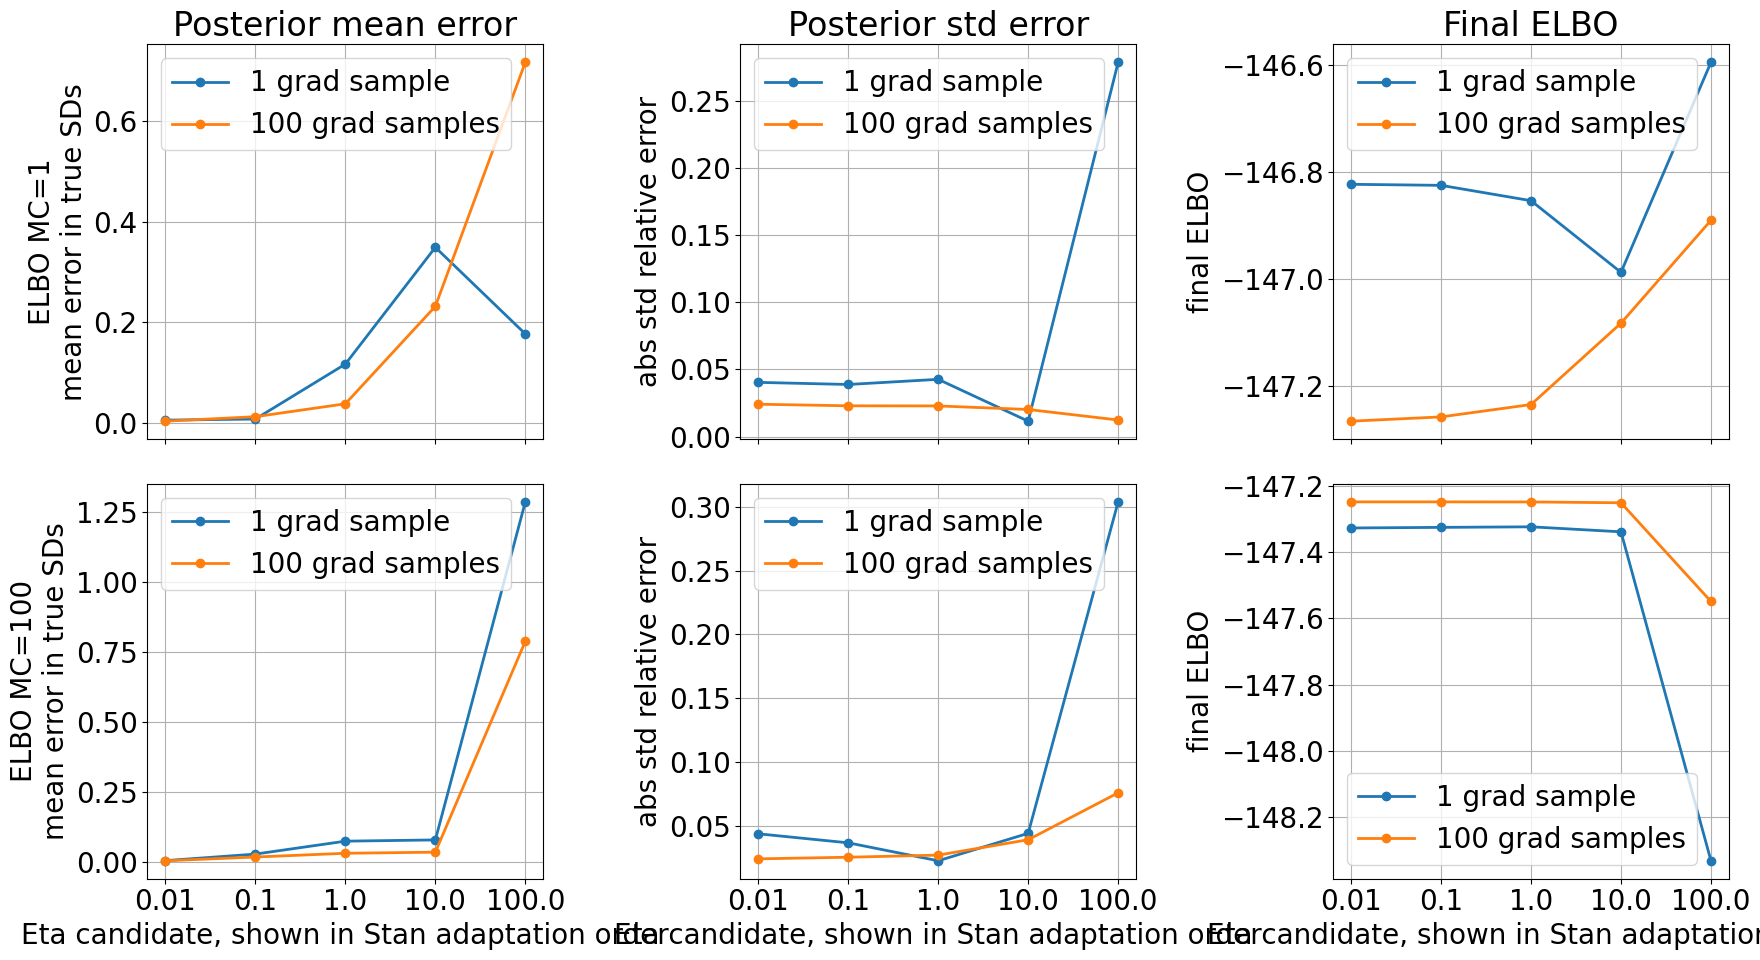

In [8]:
GRAD_SAMPLE_GRID = [1, inc_grad_samples]
ELBO_SAMPLE_GRID = [1, 100]
FIXED_ETA_GRAD_ELBO_DIR = RUN_OUTPUT_DIR / "fixed_eta_grad_elbo_grid"
FIXED_ETA_GRAD_ELBO_DIR.mkdir(exist_ok=True)


def run_fixed_eta_grad_elbo_advi(grad_samples, elbo_samples, eta):
    run_dir = (
        FIXED_ETA_GRAD_ELBO_DIR
        / f"grad_samples_{grad_samples}"
        / f"elbo_samples_{elbo_samples}"
        / f"eta_{_eta_label(eta)}"
    )
    run_dir.mkdir(parents=True, exist_ok=True)
    csv_path = run_dir / "output.csv"
    diagnostic_path = run_dir / "diagnostic.csv"
    stdout_path = run_dir / "stdout.txt"

    cmd = [
        str(model.exe_file),
        "random", f"seed={SEED}",
        "data", f"file={DATA_JSON}",
        "output", f"file={csv_path}", f"diagnostic_file={diagnostic_path}", "refresh=100",
        "method=variational", "algorithm=meanfield",
        f"iter={ADVI_ITERS}", f"eval_elbo={ADVI_EVAL_ELBO}", f"tol_rel_obj={ADVI_TOL_REL_OBJ}",
        f"grad_samples={grad_samples}", f"elbo_samples={elbo_samples}", f"eta={eta}",
        "adapt", "engaged=0",
    ]
    completed = subprocess.run(cmd, capture_output=True, text=True)
    stdout_path.write_text(completed.stdout + completed.stderr)

    row = {
        "grad_samples": grad_samples,
        "elbo_samples": elbo_samples,
        "eta": eta,
        "returncode": completed.returncode,
        "csv_file": str(csv_path),
        "diagnostic_file": str(diagnostic_path),
    }
    if completed.returncode == 0:
        row.update(_read_variational_csv(csv_path))
        row.update(_read_elbo_csv(diagnostic_path))
    else:
        row.update({
            "mu_mean": np.nan, "sample_mean": np.nan, "mu_std": np.nan,
            "n_draws": 0, "final_elbo": np.nan, "best_elbo": np.nan, "n_elbo_evals": 0,
        })
    row["mu_mean_error"] = row["mu_mean"] - true_mu_post
    row["mu_mean_abs_error_true_sds"] = abs(row["mu_mean_error"]) / true_sigma_post
    row["mu_std_error"] = row["mu_std"] - true_sigma_post
    row["mu_std_relative_error"] = row["mu_std_error"] / true_sigma_post
    return row


fixed_eta_grad_elbo_summary = pd.DataFrame(
    [
        run_fixed_eta_grad_elbo_advi(grad_samples, elbo_samples, eta)
        for elbo_samples in ELBO_SAMPLE_GRID
        for grad_samples in GRAD_SAMPLE_GRID
        for eta in ETA_SEQUENCE
    ]
)

mc_cols = [
    "elbo_samples", "grad_samples", "eta", "mu_mean", "mu_std",
    "mu_mean_abs_error_true_sds", "mu_std_relative_error",
    "final_elbo", "best_elbo", "n_elbo_evals", "returncode",
]
display(
    fixed_eta_grad_elbo_summary[mc_cols]
    .sort_values(["elbo_samples", "eta", "grad_samples"], ascending=[True, False, True])
)

fig, axs = plt.subplots(len(ELBO_SAMPLE_GRID), 3, figsize=(18, 10), sharex=True)
if len(ELBO_SAMPLE_GRID) == 1:
    axs = np.asarray([axs])

for row_idx, elbo_samples in enumerate(ELBO_SAMPLE_GRID):
    subset = fixed_eta_grad_elbo_summary[fixed_eta_grad_elbo_summary["elbo_samples"] == elbo_samples]
    for grad_samples, group in subset.groupby("grad_samples"):
        group = group.sort_values("eta", ascending=False)
        label = f"{grad_samples} grad sample" + ("s" if grad_samples != 1 else "")
        axs[row_idx, 0].plot(group["eta"], group["mu_mean_abs_error_true_sds"], marker="o", linewidth=2, label=label)
        axs[row_idx, 1].plot(group["eta"], group["mu_std_relative_error"].abs(), marker="o", linewidth=2, label=label)
        axs[row_idx, 2].plot(group["eta"], group["final_elbo"], marker="o", linewidth=2, label=label)

    axs[row_idx, 0].set_ylabel(f"ELBO MC={elbo_samples}\nmean error in true SDs")
    axs[row_idx, 1].set_ylabel("abs std relative error")
    axs[row_idx, 2].set_ylabel("final ELBO")
    for col_idx in range(3):
        axs[row_idx, col_idx].grid()
        axs[row_idx, col_idx].legend()

axs[0, 0].set_title("Posterior mean error")
axs[0, 1].set_title("Posterior std error")
axs[0, 2].set_title("Final ELBO")
for ax in axs[-1, :]:
    ax.set_xlabel("Eta candidate, shown in Stan adaptation order")

for ax in axs.ravel():
    ax.set_xscale("log")
    ax.invert_xaxis()
    ax.set_xticks(ETA_SEQUENCE)
    ax.set_xticklabels([str(eta) for eta in ETA_SEQUENCE])

plt.tight_layout()
plt.show()


## Posterior Summary Plots

These are the Stan equivalents of the two-panel 1D Gaussian plots: posterior standard deviation of `mu` on top and posterior mean of `mu` below. Blue is the default ADVI run, green is the 100-gradient-sample ADVI run, purple is pathfinder, and red is the exact conjugate posterior.


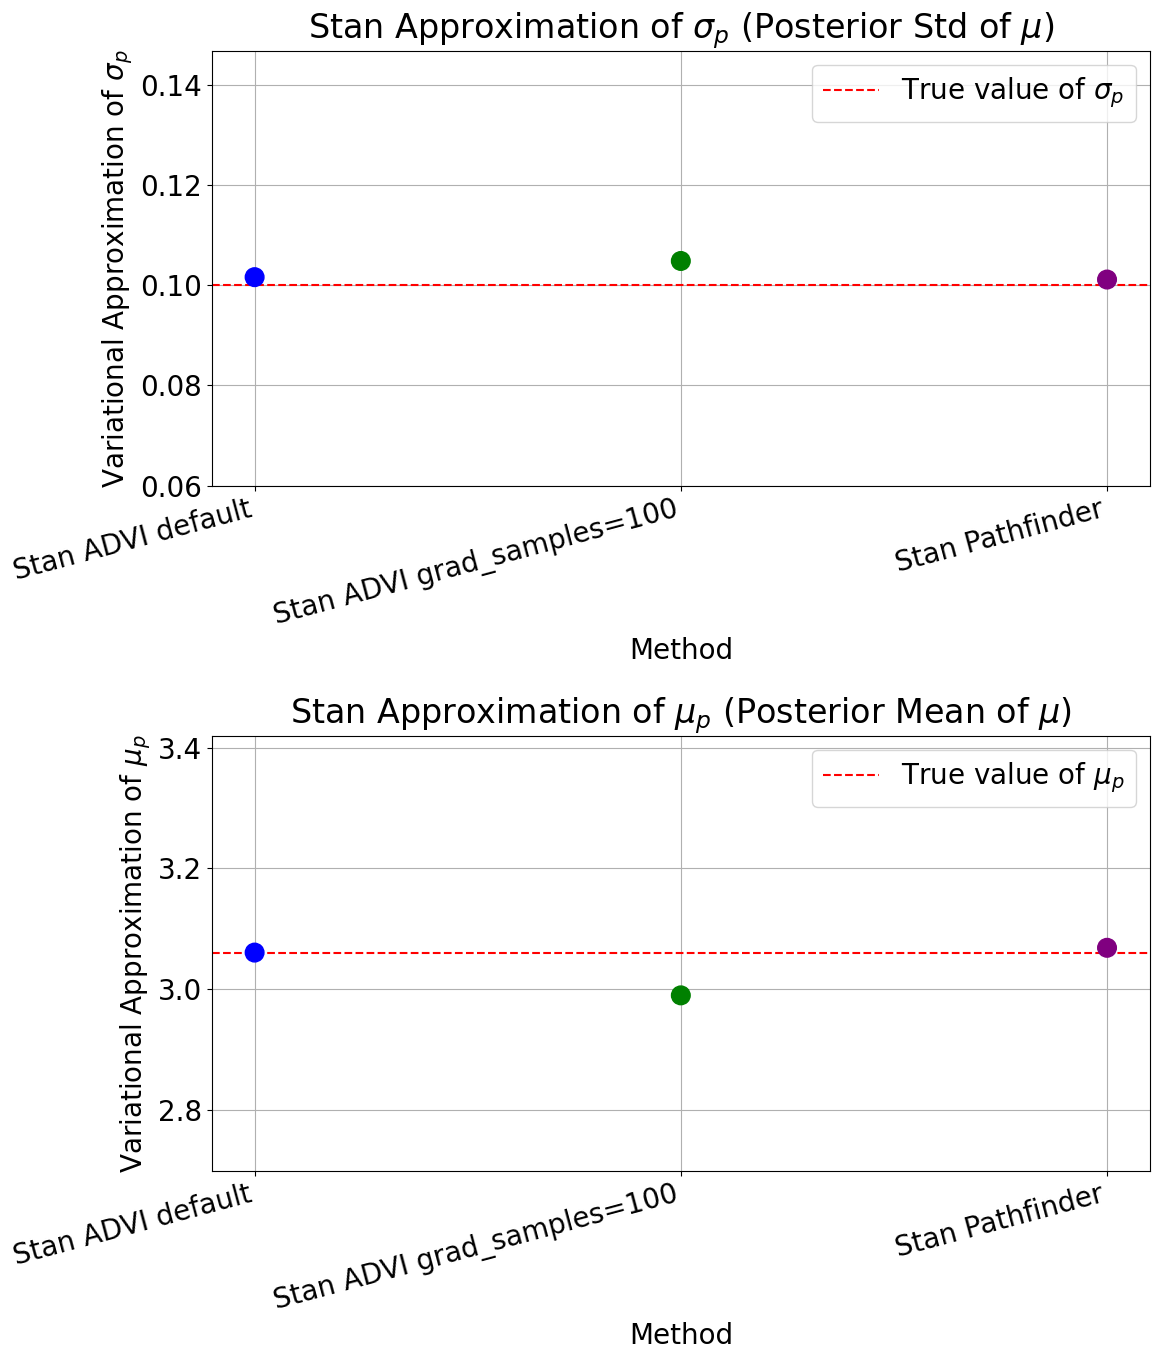

In [9]:
colors = {
    DEFAULT_LABEL: "blue",
    GRAD_LABEL: "green",
    PATHFINDER_LABEL: "purple",
}

x = np.arange(len(summary))
labels = summary["method"].tolist()
point_colors = [colors[label] for label in labels]

fig, axs = plt.subplots(2, 1, figsize=(12, 14))

axs[0].scatter(x, summary["mu_std"], s=180, color=point_colors, zorder=3)
axs[0].axhline(true_sigma_post, color="red", linestyle="--", label=r"True value of $\sigma_p$")
axs[0].set_title(r"Stan Approximation of $\sigma_p$ (Posterior Std of $\mu$)")
axs[0].set_xlabel("Method")
axs[0].set_ylabel(r"Variational Approximation of $\sigma_p$")
axs[0].set_xticks(x)
axs[0].set_xticklabels(labels, rotation=15, ha="right")
axs[0].grid()
axs[0].legend()
std_low = max(0.0, min(summary["mu_std"].min(), true_sigma_post) * 0.6)
std_high = max(summary["mu_std"].max(), true_sigma_post) * 1.4
axs[0].set_ylim(std_low, std_high)

axs[1].scatter(x, summary["mu_mean"], s=180, color=point_colors, zorder=3)
axs[1].axhline(true_mu_post, color="red", linestyle="--", label=r"True value of $\mu_p$")
axs[1].set_title(r"Stan Approximation of $\mu_p$ (Posterior Mean of $\mu$)")
axs[1].set_xlabel("Method")
axs[1].set_ylabel(r"Variational Approximation of $\mu_p$")
axs[1].set_xticks(x)
axs[1].set_xticklabels(labels, rotation=15, ha="right")
axs[1].grid()
axs[1].legend()
mean_low = min(summary["mu_mean"].min(), true_mu_post - 3 * true_sigma_post)
mean_high = max(summary["mu_mean"].max(), true_mu_post + 3 * true_sigma_post)
mean_pad = 0.1 * max(mean_high - mean_low, true_sigma_post)
axs[1].set_ylim(mean_low - mean_pad, mean_high + mean_pad)

plt.tight_layout()
plt.show()


## ADVI ELBO Trajectories

CmdStan's latent dynamics file gives ELBO traces for ADVI. This is the part of the Stan output that is naturally available as an iteration trajectory.


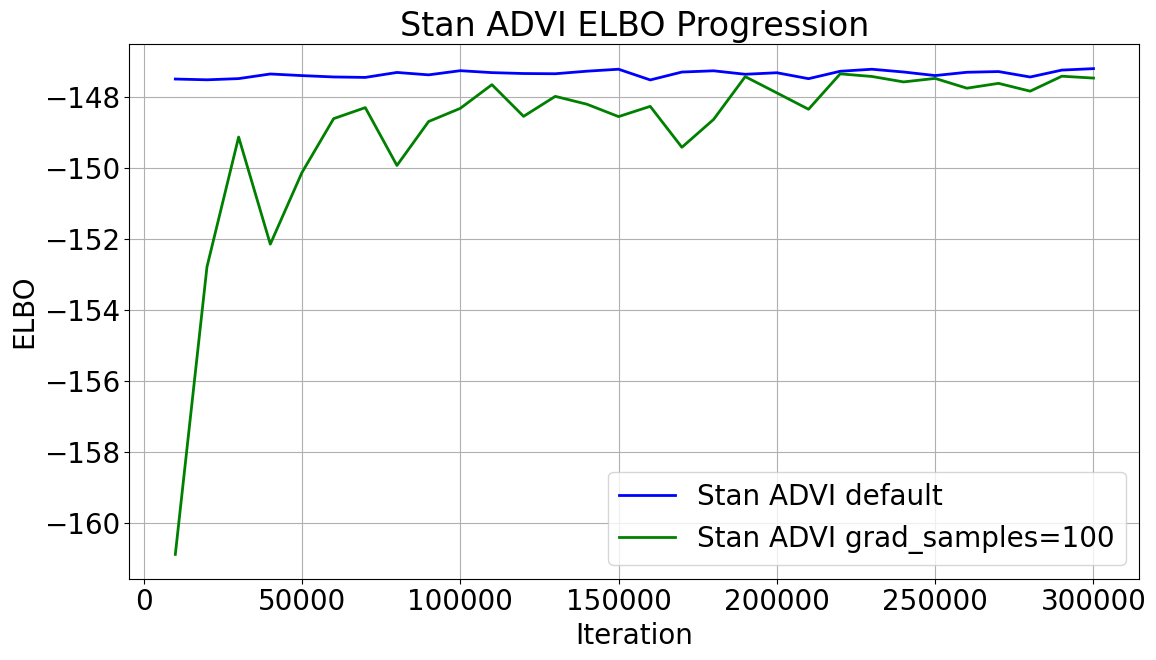

In [10]:
fig, ax = plt.subplots(figsize=(12, 7))
for method, group in elbo_history.groupby("method"):
    ax.plot(group["iter"], group["ELBO"], label=method, color=colors[method], linewidth=2)

ax.set_title("Stan ADVI ELBO Progression")
ax.set_xlabel("Iteration")
ax.set_ylabel("ELBO")
ax.grid()
ax.legend()
plt.tight_layout()
plt.show()


## Posterior Samples

This last check shows the sample-based approximations against the exact Gaussian posterior density for `mu`.


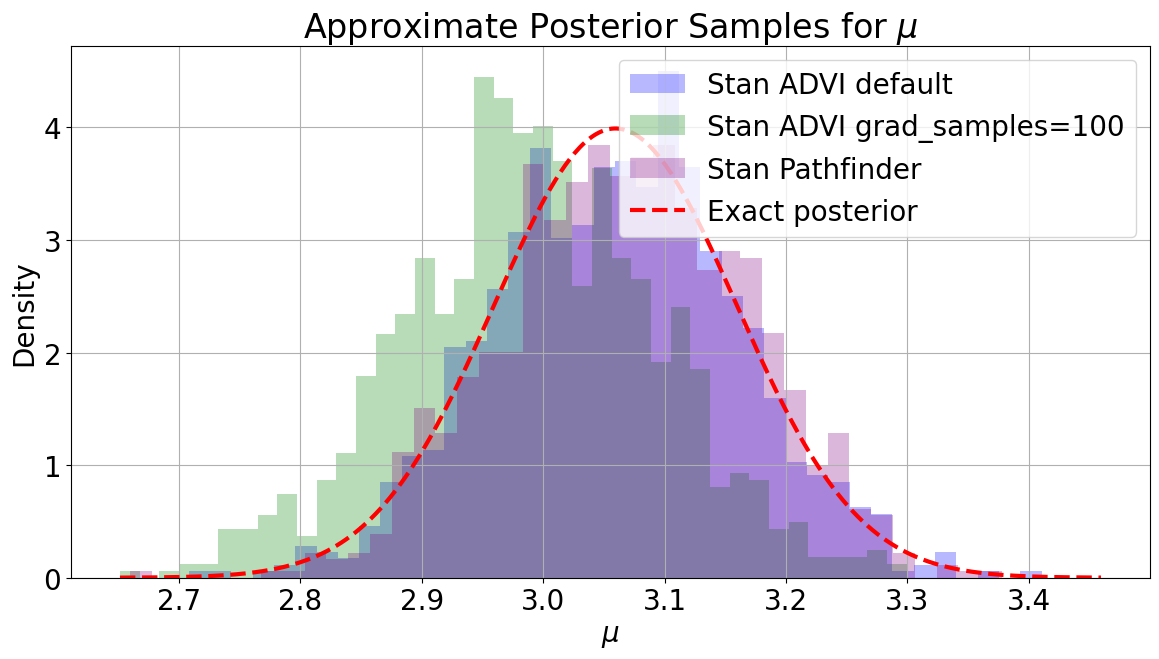

In [11]:
sample_sets = {
    DEFAULT_LABEL: np.asarray(advi_default.stan_variable("mu", mean=False), dtype=float).reshape(-1),
    GRAD_LABEL: np.asarray(advi_grad_inc.stan_variable("mu", mean=False), dtype=float).reshape(-1),
    PATHFINDER_LABEL: np.asarray(pathfinder_fit.stan_variable("mu"), dtype=float).reshape(-1),
}

grid_low = min(min(samples.min() for samples in sample_sets.values()), true_mu_post - 4 * true_sigma_post)
grid_high = max(max(samples.max() for samples in sample_sets.values()), true_mu_post + 4 * true_sigma_post)
grid = np.linspace(grid_low, grid_high, 400)
true_density = np.exp(-0.5 * ((grid - true_mu_post) / true_sigma_post) ** 2) / (true_sigma_post * np.sqrt(2 * np.pi))

fig, ax = plt.subplots(figsize=(12, 7))
for method, samples in sample_sets.items():
    ax.hist(samples, bins=40, density=True, alpha=0.28, color=colors[method], label=method)
ax.plot(grid, true_density, color="red", linestyle="--", linewidth=3, label="Exact posterior")
ax.set_title(r"Approximate Posterior Samples for $\mu$")
ax.set_xlabel(r"$\mu$")
ax.set_ylabel("Density")
ax.grid()
ax.legend()
plt.tight_layout()
plt.show()
